# Project GEO876 - Wildfire Mapping
Janis Büchel

### Setup and API

Required packages:

In [1]:
# Install Packages:

import pandas as pd
import numpy as np
from datetime import datetime
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import folium
import matplotlib.colors as mcolors
import branca.colormap as cm

To access the API, a map key is required, which can be requested on the website.

In [2]:
#Set map key:
MAP_KEY = "e5b967caf968ec1283cb213a30e9b9d4"

# Set base url:
url = "https://firms.modaps.eosdis.nasa.gov/api/"



### Data Availability


Show which sensors are available on the API:

In [3]:
# Create the correct API-url with the map key and show the list of sensors.
data_availability_url = f"{url}data_availability/csv/{MAP_KEY}/all"
df_data_avialiability = pd.read_csv(data_availability_url)

print("Following sensors are available:")
display(df_data_avialiability)



Following sensors are available:


,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-15
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-04-01,2026-05-15
3,VIIRS_NOAA20_SP,2018-04-01,2026-03-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-15
5,VIIRS_SNPP_NRT,2026-04-01,2026-05-15
6,VIIRS_SNPP_SP,2012-01-20,2026-03-31
7,LANDSAT_NRT,2022-06-20,2026-05-14
8,GOES_NRT,2022-08-09,2026-05-15
9,BA_MODIS,2000-11-01,2026-02-01


Filter for sensors which recorded wildfired today

In [4]:
# Convert max_date into a date
df_data_avialiability["max_date"] = pd.to_datetime(df_data_avialiability['max_date'])

# Date of today
date_today = pd.Timestamp.now().normalize()
print(f"Date today: {date_today}\n")

# Filter for sensors with recordings today
df_available_sens = df_data_avialiability[df_data_avialiability["max_date"] == date_today]
print(f"Sensors with up to date data: \n {df_available_sens}")


Date today: 2026-05-15 00:00:00

Sensors with up to date data: 
             data_id    min_date   max_date
0         MODIS_NRT  2026-02-01 2026-05-15
2  VIIRS_NOAA20_NRT  2026-04-01 2026-05-15
4  VIIRS_NOAA21_NRT  2024-01-17 2026-05-15
5    VIIRS_SNPP_NRT  2026-04-01 2026-05-15
8          GOES_NRT  2022-08-09 2026-05-15


### Data Collection

Collect data for one sensor (MODIS):

In [5]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensor = "MODIS_NRT"
focus_area = "world"
day_range = 2 # max. 5 days

area_url = f"{url}area/csv/{MAP_KEY}/{sensor}/{focus_area}/{day_range}"
df_area = pd.read_csv(area_url)

df_area

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,0.49157,127.98701,311.80,1.43,1.18,2026-05-14,5,Terra,MODIS,45,6.1NRT,294.03,10.66,D
1,0.78403,127.37922,311.27,1.60,1.25,2026-05-14,5,Terra,MODIS,0,6.1NRT,292.73,12.21,D
2,1.49468,127.63360,336.45,1.57,1.24,2026-05-14,5,Terra,MODIS,89,6.1NRT,295.01,65.97,D
3,-1.56707,127.42722,313.54,1.46,1.19,2026-05-14,7,Terra,MODIS,44,6.1NRT,295.26,11.09,D
4,-18.60654,134.14061,308.05,2.13,1.42,2026-05-14,9,Terra,MODIS,30,6.1NRT,294.58,12.16,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8848,9.83086,-69.75756,315.08,1.37,1.16,2026-05-15,1353,Terra,MODIS,65,6.1NRT,300.24,10.54,D
8849,9.92230,-72.56990,312.14,1.02,1.01,2026-05-15,1353,Terra,MODIS,55,6.1NRT,297.12,4.54,D
8850,-13.65052,-68.84921,301.06,3.80,1.82,2026-05-15,1357,Terra,MODIS,32,6.1NRT,286.12,13.14,D
8851,-34.94150,-72.11050,324.90,3.80,1.82,2026-05-15,1403,Terra,MODIS,68,6.1NRT,280.66,177.80,D


Collect data for all three VIIRS sensors:

In [6]:
# Shows the data of the sensor for the desired area (world = [-180,-90,180,90]) and for the day range.
sensors = ["VIIRS_NOAA20_NRT", "VIIRS_NOAA21_NRT", "VIIRS_SNPP_NRT"]
focus_area = "world"
day_range = 2 # max. 5 days

# df for with data from all three sensors:
df_viirs = []

for foc_sensor in sensors:
    area_url = f"{url}area/csv/{MAP_KEY}/{foc_sensor}/{focus_area}/{day_range}"
    df_sens = pd.read_csv(area_url)
    df_sens["sensor_id"] = foc_sensor
    df_viirs.append(df_sens)
    print(f"Data for {foc_sensor} loaded, total {len(df_sens)} rows.")

# Add all three dataframes into one big dataframe
df_viirs = pd.concat(df_viirs, ignore_index=True)
print(f"Total number of rows: {len(df_viirs)}\nFinal df:")
display(df_viirs.tail())

Data for VIIRS_NOAA20_NRT loaded, total 54581 rows.
Data for VIIRS_NOAA21_NRT loaded, total 50433 rows.
Data for VIIRS_SNPP_NRT loaded, total 56752 rows.
Total number of rows: 161766
Final df:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,sensor_id
161761,31.66301,6.05555,348.34,0.55,0.68,2026-05-15,1342,N,VIIRS,n,2.0NRT,297.21,7.84,D,VIIRS_SNPP_NRT
161762,31.66333,6.06147,341.19,0.55,0.68,2026-05-15,1342,N,VIIRS,n,2.0NRT,296.65,7.95,D,VIIRS_SNPP_NRT
161763,31.66426,6.05155,341.04,0.55,0.68,2026-05-15,1342,N,VIIRS,n,2.0NRT,297.13,4.40,D,VIIRS_SNPP_NRT
161764,31.66455,6.05752,348.08,0.55,0.68,2026-05-15,1342,N,VIIRS,n,2.0NRT,297.00,4.40,D,VIIRS_SNPP_NRT
161765,31.75160,5.22806,348.21,0.49,0.65,2026-05-15,1342,N,VIIRS,n,2.0NRT,300.06,3.16,D,VIIRS_SNPP_NRT


Filter for data with condicence nominal or high:

In [7]:
df_viirs = df_viirs[(df_viirs["confidence"] == "n") | (df_viirs["confidence"] == "h")].copy()
print(f"{len(df_viirs)} rows with confidence nominal or high")

147807 rows with confidence nominal or high


Change acq_date und acq_time to datetime:

In [8]:
df_viirs["acq_time"] = df_viirs["acq_time"].astype(str) # Convert time to string
df_viirs["acq_time"] = df_viirs["acq_time"].str.zfill(4) # Fill with zeros

# Create new column with datetime
df_viirs["acq_datetime"] = pd.to_datetime(
    df_viirs["acq_date"] + " " + df_viirs["acq_time"], 
    format='%Y-%m-%d %H%M'
)
# Print new column
print(df_viirs[["acq_datetime"]].head())

         acq_datetime
0 2026-05-14 00:56:00
1 2026-05-14 01:09:00
2 2026-05-14 01:09:00
3 2026-05-14 01:09:00
4 2026-05-14 01:11:00


Filter for data from the last 24h

In [9]:
from datetime import datetime, timedelta

date_24h = datetime.now() - timedelta(hours=24 + 2) # plus 2h to get the utc time

# keep only data from the past 24h
df_viirs_24h = df_viirs[df_viirs["acq_datetime"] >= date_24h].copy()

print(f"date and time 24h ago (utc): {date_24h}")
print(f"number of rows from the past 24h: {len(df_viirs_24h)}")

date and time 24h ago (utc): 2026-05-14 15:21:32.857268
number of rows from the past 24h: 82468


Rename columns and display final df

In [10]:
# Select columns
df_viirs_fin = df_viirs_24h[["acq_datetime",
                         "sensor_id",
                         "latitude",
                         "longitude",
                         "bright_ti4",
                         "bright_ti5",
                         "frp",
                         "confidence",
                         "daynight"]].copy()


# Rename columns
df_viirs_fin = df_viirs_fin.rename(columns={
    "acq_datetime": "date/time",
    "latitude": "latitude",
    "longitude": "longitude",
    "bright_ti4": "fire_temperature_k",
    "bright_ti5": "ground_temperature_k",
    "frp": "intensity_mv",
    "sensor_id": "sensor",
    "confidence": "confidence"
})

# Add column withfire_temperature in °C
df_viirs_fin["fire_temperature_c"] = df_viirs_fin["fire_temperature_k"] - 273.15

# Show final dataframe
display(df_viirs_fin.tail())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mv,confidence,daynight,fire_temperature_c
161761,2026-05-15 13:42:00,VIIRS_SNPP_NRT,31.66301,6.05555,348.34,297.21,7.84,n,D,75.19
161762,2026-05-15 13:42:00,VIIRS_SNPP_NRT,31.66333,6.06147,341.19,296.65,7.95,n,D,68.04
161763,2026-05-15 13:42:00,VIIRS_SNPP_NRT,31.66426,6.05155,341.04,297.13,4.40,n,D,67.89
161764,2026-05-15 13:42:00,VIIRS_SNPP_NRT,31.66455,6.05752,348.08,297.00,4.40,n,D,74.93
161765,2026-05-15 13:42:00,VIIRS_SNPP_NRT,31.75160,5.22806,348.21,300.06,3.16,n,D,75.06


Create two datasets, one for the day and one for the night

In [11]:
df_viirs_night = df_viirs_fin[(df_viirs_fin["daynight"] == "N")].copy()
df_viirs_day = df_viirs_fin[(df_viirs_fin["daynight"] == "D")].copy()
print(f"Rows detected at night: {len(df_viirs_night)}\nRows detected at day: {len(df_viirs_day)}")

Rows detected at night: 22502
Rows detected at day: 59966


### Create GeoDataFrame

Convert dataframe to geodataframe

In [12]:
gdf_viirs = gpd.GeoDataFrame(
    df_viirs_fin, 
    geometry=gpd.points_from_xy(df_viirs_fin.longitude, df_viirs_fin.latitude),
    crs="EPSG:4326"  # WGS84
)

display(gdf_viirs.head())

,date/time,sensor,latitude,longitude,fire_temperature_k,ground_temperature_k,intensity_mv,confidence,daynight,fire_temperature_c,geometry
23370,2026-05-14 15:46:00,VIIRS_NOAA20_NRT,-25.47945,-43.94403,347.55,289.02,7.89,n,D,74.40,POINT (-43.94403 -25.47945)
23371,2026-05-14 15:46:00,VIIRS_NOAA20_NRT,-25.47753,-43.94466,355.73,288.81,12.67,n,D,82.58,POINT (-43.94466 -25.47753)
23372,2026-05-14 15:48:00,VIIRS_NOAA20_NRT,-17.59766,-41.42708,348.19,279.11,0.86,n,D,75.04,POINT (-41.42708 -17.59766)
23373,2026-05-14 15:48:00,VIIRS_NOAA20_NRT,-14.55777,-39.65070,329.43,285.25,3.85,n,D,56.28,POINT (-39.6507 -14.55777)
23374,2026-05-14 15:48:00,VIIRS_NOAA20_NRT,-14.26246,-39.18692,338.22,284.78,10.64,n,D,65.07,POINT (-39.18692 -14.26246)


Create a quick test plot:

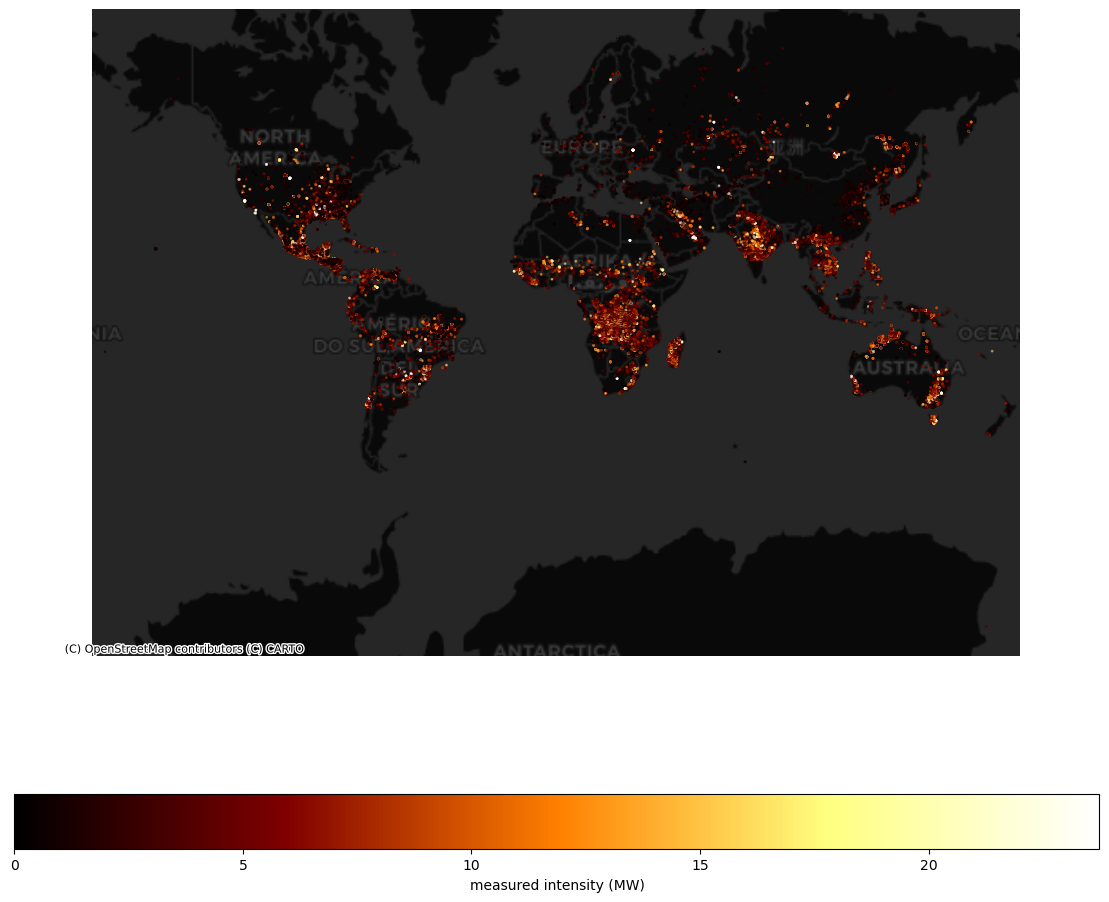

A difference in temperature can be seen between West and East. The data in Asia and Australia was collected during the day, whereas the data in Europe and America was collected during night


In [13]:
# Set CRS to Web Mercator to match contextily basemap
gdf_viirs = gdf_viirs.to_crs(epsg=3857)

# Create the initial plot
fig, ax = plt.subplots(figsize=(20, 12))

vmax = np.percentile(gdf_viirs["intensity_mv"], 95)

# Plot the data
gdf_viirs.plot(ax=ax,
               column="intensity_mv",
               legend=True,
               alpha=0.5,
               markersize=1,
               vmax=vmax,
               cmap="afmhot",
               legend_kwds={
                   "label": "measured intensity (MW)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

# Add a basemap
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.DarkMatter)

# Hide axes
ax.set_axis_off()
plt.show()

print("A difference in temperature can be seen between West and East. " \
"The data in Asia and Australia was collected during the day, whereas the data in Europe and America was collected during night")

Create a test plot for day and night


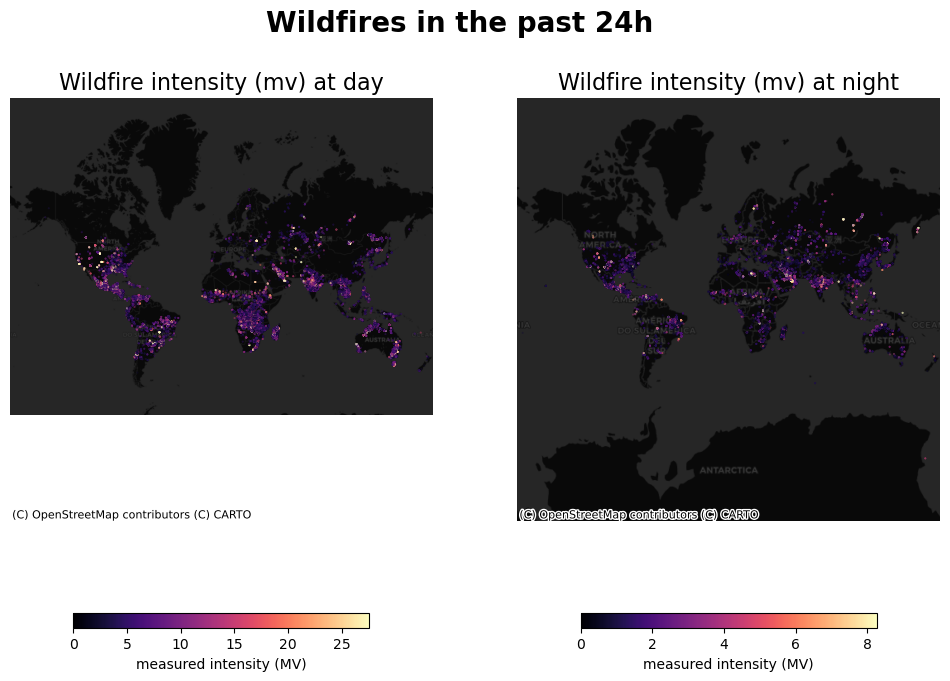

In [14]:
gdf_viirs_day = gpd.GeoDataFrame(
    df_viirs_day, 
    geometry=gpd.points_from_xy(df_viirs_day.longitude, df_viirs_day.latitude),
    crs="EPSG:4326"  # WGS84
).to_crs(epsg=3857)

gdf_viirs_night = gpd.GeoDataFrame(
    df_viirs_night, 
    geometry=gpd.points_from_xy(df_viirs_night.longitude, df_viirs_night.latitude),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Plot with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Filter for outliers
vmax_day = np.percentile(gdf_viirs_day["intensity_mv"], 95)

gdf_viirs_day.plot(ax=axs[0],
               column="intensity_mv",
               legend=True,
               markersize=0.2,
               alpha=0.5,
               vmax=vmax_day,
               cmap="magma",
               legend_kwds={
                   "label": "measured intensity (MV)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

vmax_night = np.percentile(gdf_viirs_night["intensity_mv"], 95)

gdf_viirs_night.plot(ax=axs[1],
               column="intensity_mv",
               legend=True,
               markersize=0.2,
               alpha=0.5,
               vmax=vmax_night,
               cmap="magma",
               legend_kwds={
                   "label": "measured intensity (MV)",
                   "orientation": "horizontal",
                   "shrink":0.7
    })

# Add a basemap
ctx.add_basemap(ax=axs[0], source=ctx.providers.CartoDB.DarkMatter)
ctx.add_basemap(ax=axs[1], source=ctx.providers.CartoDB.DarkMatter)

# Set a title
fig.suptitle("Wildfires in the past 24h", fontsize=20, fontweight="bold")
axs[0].set_title("Wildfire intensity (mv) at day", fontsize=16, color="k")
axs[1].set_title("Wildfire intensity (mv) at night", fontsize=16, color="k")

for ax in axs:
    ax.set_xlim(-20000000, 20000000)
    ax.set_ylim(-20000000, 20000000)

# Hide axes
axs[0].set_axis_off()
axs[1].set_axis_off()
plt.show()

Create an interactive plot

In [16]:
# Set CRS back to WGS84
gdf = gdf_viirs.to_crs(epsg=4326).copy()

# Filter for outliers
vmax = np.percentile(gdf["intensity_mv"], 95)
vmin = gdf["intensity_mv"].min()

# Set Colormap
cmap = plt.get_cmap("magma")
norm = mcolors.Normalize(vmin=0, vmax=vmax)

# Set up legend
legend = cm.LinearColormap(
    colors=[mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, 6)],
    vmin=vmin,
    vmax=vmax,
    caption="Fire Intensity (MW)"
)

# Set center
center_lat = gdf.geometry.y.mean()
center_lon = gdf.geometry.x.mean()

# Create Folium map
map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=3,
    tiles="CartoDB dark_matter"
)

# Add data
for idx, row in gdf.iterrows():
    lon = row.geometry.y
    lat = row.geometry.x

    value = min(row["intensity_mv"], vmax)

    rgb = cmap(norm(value))
    color = mcolors.to_hex(rgb)

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        color=color,
        fill_color=color,
        tooltip=f"Date and time: {str(row["date/time"])}"
    ).add_to(map)

# Add legend
legend.add_to(map)
style = '<style>.legend {background: white !important; padding: 10px; border-radius: 5px;} .legend svg text {fill: black !important;}</style>'
map.get_root().header.add_child(folium.Element(style))

# Add title
title_html = '<h1 style="position:fixed; top:50px; left:100px; z-index:9999; color:white; font-family:sans-serif;">Wildfire Intensity Map</h1>'
map.get_root().html.add_child(folium.Element(title_html))

# Show map
map
map.save("../data/wildfire_map.html")